In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from pathlib import Path

outdir = '/mnt/hdcasa/splus_gaia/mc_catalogs/'


def concat_fields(outdir, pattern):

    pasta = Path(outdir)

    files = sorted(pasta.glob(pattern))

    full = pd.concat(
        (pd.read_csv(f) for f in files),
        ignore_index=True
    )
    return full

In [3]:
mc_fields = concat_fields(outdir, 'MC*.csv')

/tmp/ipykernel_32330/2480420889.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full = pd.concat(


In [4]:
mc_fields.size

1210689747

In [5]:
mc_fields_clean = mc_fields[(mc_fields['err_mag_psf_j0660'] < 0.2)&
        (mc_fields['err_mag_psf_i'] < 0.2)&
        (mc_fields['err_mag_psf_r'] < 0.2)&
        (mc_fields['mag_psf_j0660']/mc_fields['err_mag_psf_j0660'] > 10)&
        (mc_fields['mag_psf_i']/mc_fields['err_mag_psf_i'] > 10)&
        (mc_fields['mag_psf_r']/mc_fields['err_mag_psf_r'] > 10)&
        mc_fields['mag_psf_r'].between(13,19.5)]

In [6]:
import numpy as np

def sample_objects_in_nonoverlapping_apertures(
    df,
    ra_col: str,
    dec_col: str,
    ra_min: float,
    ra_max: float,
    dec_min: float,
    dec_max: float,
    n_apertures: int = 100,
    radius_arcmin: float = 1.0,
    cols: list[str] | None = None,
    seed: int | None = 0,
    max_tries: int = 200000,
    return_type: str = "pandas",  # "pandas" ou "polars"
):
    """
    Cria N aberturas circulares aleatórias de mesmo raio, NÃO sobrepostas,
    dentro de uma caixa (ra_min/ra_max/dec_min/dec_max), e retorna os objetos
    dentro de cada abertura.

    Não sobreposição: distância entre centros >= 2*raio.

    Retorna:
      apertures: list[dict] com centros/raio
      results:   list[DF] (1 DF por abertura) com objetos dentro, + metadados
    """
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    # --- detectar pandas vs polars e pegar arrays
    is_polars = df.__class__.__module__.startswith("polars")
    if is_polars:
        import polars as pl
        ra = df[ra_col].to_numpy()
        dec = df[dec_col].to_numpy()
        if cols is None:
            cols = df.columns
        if ra_col not in cols: cols = [ra_col] + cols
        if dec_col not in cols: cols = [dec_col] + cols
    else:
        ra = df[ra_col].to_numpy()
        dec = df[dec_col].to_numpy()
        if cols is None:
            cols = list(df.columns)
        if ra_col not in cols: cols = [ra_col] + cols
        if dec_col not in cols: cols = [dec_col] + cols

    ra = np.asarray(ra, float)
    dec = np.asarray(dec, float)
    cat = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")

    r = (radius_arcmin * u.arcmin)
    r_deg = r.to(u.deg).value

    # margem para garantir círculo inteiro dentro da caixa
    dec_abs_max = max(abs(dec_min), abs(dec_max))
    cos_min = np.cos(np.deg2rad(dec_abs_max))
    cos_min = max(cos_min, 1e-6)
    ra_margin = r_deg / cos_min

    ra_lo = ra_min + ra_margin
    ra_hi = ra_max - ra_margin
    dec_lo = dec_min + r_deg
    dec_hi = dec_max - r_deg

    if ra_lo >= ra_hi or dec_lo >= dec_hi:
        raise ValueError(
            "A área é pequena demais para acomodar a abertura com margem. "
            "Diminua radius_arcmin ou aumente a área."
        )

    rng = np.random.default_rng(seed)

    # separação mínima entre centros para não sobrepor círculos
    min_center_sep = (2.0 * r)  # 2*raio

    centers_list = []  # SkyCoord individuais
    apertures = []
    results = []

    # --- loop de amostragem por rejeição
    tries = 0
    while len(centers_list) < n_apertures and tries < max_tries:
        tries += 1

        cra = rng.uniform(ra_lo, ra_hi)
        cdec = rng.uniform(dec_lo, dec_hi)
        c0 = SkyCoord(ra=cra*u.deg, dec=cdec*u.deg, frame="icrs")

        if centers_list:
            prev = SkyCoord(centers_list)
            # checa se está perto demais de algum centro já aceito
            if np.any(c0.separation(prev) < min_center_sep):
                continue

        centers_list.append(c0)

    if len(centers_list) < n_apertures:
        raise RuntimeError(
            f"Não consegui posicionar {n_apertures} aberturas não sobrepostas "
            f"nessa área com raio={radius_arcmin} arcmin. "
            f"Consegui {len(centers_list)} após {tries} tentativas. "
            "Sugestões: aumente a área, reduza o raio, ou reduza n_apertures."
        )

    # --- agora seleciona objetos dentro de cada abertura
    for k, c0 in enumerate(centers_list):
        sep = cat.separation(c0)
        m = sep <= r

        apertures.append({
            "aperture_id": k,
            "center_ra": float(c0.ra.deg),
            "center_dec": float(c0.dec.deg),
            "radius_arcmin": float(radius_arcmin),
        })

        if is_polars:
            import polars as pl
            sub = df.select(cols).filter(pl.Series(m))
            sub = sub.with_columns([
                pl.lit(k).alias("aperture_id"),
                pl.lit(float(c0.ra.deg)).alias("center_ra"),
                pl.lit(float(c0.dec.deg)).alias("center_dec"),
                pl.Series(sep.arcsec[m]).alias("sep_arcsec"),
            ])
            if return_type == "pandas":
                sub = sub.to_pandas()
        else:
            sub = df.loc[m, cols].copy()
            sub["aperture_id"] = k
            sub["center_ra"] = float(c0.ra.deg)
            sub["center_dec"] = float(c0.dec.deg)
            sub["sep_arcsec"] = sep.arcsec[m]

            if return_type == "polars":
                import polars as pl
                sub = pl.from_pandas(sub)

        results.append(sub)

    return apertures, results

In [7]:
mc_fields_clean.columns

Index(['id', 'ra', 'dec', 'mag_psf_g', 'mag_psf_i', 'mag_psf_j0378',
       'mag_psf_j0395', 'mag_psf_j0410', 'mag_psf_j0430', 'mag_psf_j0515',
       'mag_psf_j0660', 'mag_psf_j0861', 'mag_psf_r', 'mag_psf_u', 'mag_psf_z',
       'err_mag_psf_g', 'err_mag_psf_i', 'err_mag_psf_j0378',
       'err_mag_psf_j0395', 'err_mag_psf_j0410', 'err_mag_psf_j0430',
       'err_mag_psf_j0515', 'err_mag_psf_j0660', 'err_mag_psf_j0861',
       'err_mag_psf_r', 'err_mag_psf_u', 'err_mag_psf_z'],
      dtype='object')

In [8]:
fields = pd.read_csv('/home/shared/splus_gaia/data/field_catalogs/dr6_list.csv')

fields = fields[fields['field'].str.contains('MC')]

In [13]:
fields['ra'].describe()

count    146.000000
mean      58.480394
std       27.961775
min        3.954167
25%       35.566667
50%       66.916667
75%       81.531250
max       96.495833
Name: ra, dtype: float64

In [14]:
fields['dec'].describe()

count    146.000000
mean     -70.226710
std        3.387812
min      -74.692500
25%      -73.151111
50%      -70.967222
75%      -68.432222
max      -63.267778
Name: dec, dtype: float64

In [10]:
cols = ['id', 'ra', 'dec', 'mag_psf_g', 'mag_psf_i', 'mag_psf_j0378',
       'mag_psf_j0395', 'mag_psf_j0410', 'mag_psf_j0430', 'mag_psf_j0515',
       'mag_psf_j0660', 'mag_psf_j0861', 'mag_psf_r', 'mag_psf_u', 'mag_psf_z',
       'err_mag_psf_g', 'err_mag_psf_i', 'err_mag_psf_j0378',
       'err_mag_psf_j0395', 'err_mag_psf_j0410', 'err_mag_psf_j0430',
       'err_mag_psf_j0515', 'err_mag_psf_j0660', 'err_mag_psf_j0861',
       'err_mag_psf_r', 'err_mag_psf_u', 'err_mag_psf_z']

apertures, results = sample_objects_in_nonoverlapping_apertures(
    df=mc_fields_clean,
    ra_col="ra",
    dec_col="dec",
    ra_min=3.954166667, ra_max=96.49583333,
    dec_min=-74.6925, dec_max=-63.26777778,
    n_apertures=1000,
    radius_arcmin=1.0,
    cols=cols,
    seed=42,
    return_type="pandas",
)

import pandas as pd
all_in_apertures = pd.concat(results, ignore_index=True)

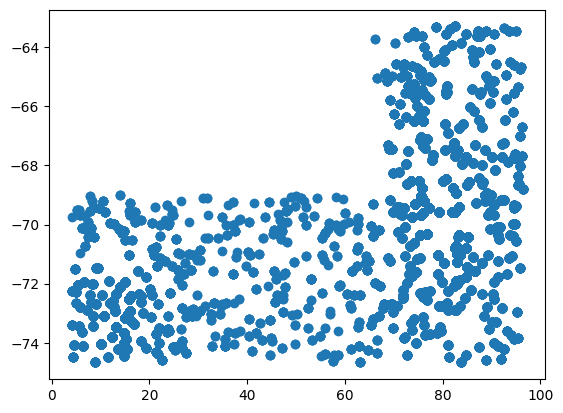

In [11]:
plt.scatter(all_in_apertures['center_ra'], all_in_apertures['center_dec'])

In [12]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord, search_around_sky, Angle
import astropy.units as u

def match_emitters_to_clusters(
    clusters: pd.DataFrame,
    stars: pd.DataFrame,
    *,
    cluster_ra_col: str = "ra",        # RA dos aglomerados (graus)
    cluster_dec_col: str = "dec",      # Dec dos aglomerados (graus)
    cluster_amaj_col: str = "amaj",    # semi-eixo maior (ex.: arcmin) — tratado como raio circular
    stars_ra_col: str = "ra",          # RA das estrelas (graus)
    stars_dec_col: str = "dec",        # Dec das estrelas (graus)
    amaj_unit: str = "arcmin",         # unidade do amaj (ex.: "arcmin", "arcsec", "deg")
    keep_cols_clusters: list | None = None,  # colunas extras do df de aglomerados para levar ao resultado
    keep_cols_stars: list | None = None,     # colunas extras do df de estrelas para levar ao resultado
) -> pd.DataFrame:
    """
    Associa estrelas Hα a aglomerados retornando apenas as que estão dentro do amaj de cada aglomerado.

    Parameters
    ----------
    clusters : pandas.DataFrame
        Tabela de aglomerados com colunas de posição e amaj.
    stars : pandas.DataFrame
        Tabela de estrelas emissoras com colunas de posição.
    cluster_ra_col : str, default "ra"
        Nome da coluna de RA dos aglomerados (em graus).
    cluster_dec_col : str, default "dec"
        Nome da coluna de Dec dos aglomerados (em graus).
    cluster_amaj_col : str, default "amaj"
        Nome da coluna do semi-eixo maior do aglomerado.
        **É interpretado como um raio circular** para a seleção.
    stars_ra_col : str, default "ra"
        Nome da coluna de RA das estrelas (em graus).
    stars_dec_col : str, default "dec"
        Nome da coluna de Dec das estrelas (em graus).
    amaj_unit : str, default "arcmin"
        Unidade de `amaj` (por exemplo: "arcmin", "arcsec" ou "deg").
    keep_cols_clusters : list[str] | None
        Colunas adicionais do DataFrame de aglomerados a incluir no resultado.
    keep_cols_stars : list[str] | None
        Colunas adicionais do DataFrame de estrelas a incluir no resultado.

    Returns
    -------
    pandas.DataFrame
        Uma tabela já mesclada contendo:
        - índices originais (`cluster_index`, `star_index`)
        - separação angular (`sep_arcsec`, `sep_arcmin`)
        - colunas dos aglomerados com prefixo `cluster_`
        - colunas das estrelas com prefixo `star_`

    Notes
    -----
    * `amaj` é tratado como **semi-eixo maior** em unidade dada por `amaj_unit` e
      usado como **raio circular equivalente** para o corte (i.e., sep <= amaj).
    * A rotina usa um raio máximo global (= max(amaj)) em `search_around_sky`
      e depois filtra par-a-par por `amaj` específico de cada aglomerado.
    * Linhas com posições/raios inválidos (NaN, não positivos) são ignoradas.
    """
    # Escolha das colunas para carregar/propagar
    if keep_cols_clusters is None:
        keep_cols_clusters = []
    if keep_cols_stars is None:
        keep_cols_stars = []

    # Filtrar entradas válidas nos aglomerados
    cl_req = [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters
    cl_df = clusters[cl_req].copy()
    cl_df = cl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[cluster_ra_col, cluster_dec_col, cluster_amaj_col])
    # descarta amaj <= 0
    cl_df = cl_df[cl_df[cluster_amaj_col] > 0].copy()

    # Filtrar entradas válidas nas estrelas
    st_req = [stars_ra_col, stars_dec_col] + keep_cols_stars
    st_df = stars[st_req].copy()
    st_df = st_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[stars_ra_col, stars_dec_col])

    if cl_df.empty or st_df.empty:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Coordenadas
    c_clusters = SkyCoord(ra=cl_df[cluster_ra_col].to_numpy() * u.deg,
                          dec=cl_df[cluster_dec_col].to_numpy() * u.deg)
    c_stars = SkyCoord(ra=st_df[stars_ra_col].to_numpy() * u.deg,
                       dec=st_df[stars_dec_col].to_numpy() * u.deg)

    # Raio máximo global para a busca
    unit = u.Unit(amaj_unit)
    max_amaj = np.nanmax(cl_df[cluster_amaj_col].to_numpy())
    seplimit = Angle(max_amaj, unit)

    # Busca inicial (eficiente)
    idx_cl, idx_st, sep2d, _ = search_around_sky(c_clusters, c_stars, seplimit=seplimit)

    if len(idx_cl) == 0:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Limite específico por aglomerado (par-a-par)
    amaj_per_pair = Angle(cl_df.iloc[idx_cl][cluster_amaj_col].to_numpy(), unit)
    keep = sep2d <= amaj_per_pair

    if not np.any(keep):
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Construir resultado
    pairs = pd.DataFrame({
        "cluster_index": cl_df.index.values[idx_cl[keep]],
        "star_index": st_df.index.values[idx_st[keep]],
        "sep_arcsec": sep2d[keep].arcsec,
        "sep_arcmin": sep2d[keep].to(u.arcmin).value,
    })

    # Anexar metadados dos aglomerados e estrelas (com prefixos)
    cl_out = clusters.loc[pairs["cluster_index"]][[cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters]
    cl_out = cl_out.add_prefix("cluster_").reset_index(drop=True)

    st_out = stars.loc[pairs["star_index"]][[stars_ra_col, stars_dec_col] + keep_cols_stars]
    st_out = st_out.add_prefix("star_").reset_index(drop=True)

    result = pd.concat([pairs.reset_index(drop=True), cl_out, st_out], axis=1)

    # Ordenar por separação (útil)
    result = result.sort_values("sep_arcmin", ascending=True).reset_index(drop=True)
    return result

In [13]:
bica =pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/FullCatalogBica_08_20_Vizier.csv')

bica_c = bica[bica['Type'].isin(['C', 'CA'])]  # apenas aglomerados do tipo "C"

In [16]:
bica.columns

Index(['Names', 'PA', 'bmin', 'l_logAge', 'logAge', 'r_logAge', '[M/H]',
       'r_[M/H]', 'PapI', 'B18', 'ra', 'dec', 'amaj', 'SimbadName', 'Type'],
      dtype='object')

In [17]:
# clusters_df: colunas ["name","ra","dec","amaj"] (amaj em arcmin, por ex.)
# emitters_df: colunas ["source_id","ra","dec", ...]
out = match_emitters_to_clusters(
    bica_c,
    all_in_apertures,
    cluster_ra_col="ra",
    cluster_dec_col="dec",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=["Names"],         # traga o nome do aglomerado
    keep_cols_stars=["id"]  # traga id/atributos da estrela
)

In [18]:
out

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra,cluster_dec,cluster_amaj,cluster_Names,star_ra,star_dec,star_id
0,1866,19565,1.029446,0.017157,15.120000,-73.876944,0.55,B98ne,15.120542,-73.877188,i06MC011501Z6P
1,5129,10645,1.389418,0.023157,15.982500,-72.933333,0.40,Piatti3,15.982296,-72.932952,i06MC01150BB6N
2,4082,14857,1.417564,0.023626,87.087500,-63.597222,0.80,KMHK1381,87.088325,-63.597079,i06MC000702YEC
3,4348,21657,1.958208,0.032637,82.545833,-67.675278,0.40,KMHK980,82.545508,-67.674748,i06MC003201S0D
4,2549,20982,2.477666,0.041294,82.587500,-69.584167,0.80,BSDL2038,82.586647,-69.583546,i06MC0065098YK
...,...,...,...,...,...,...,...,...,...,...,...
824,4913,12881,196.514044,3.275234,83.420833,-70.986667,3.30,NGC2031,83.502682,-71.034316,i06MC008808YWB
825,4913,12859,197.276242,3.287937,83.420833,-70.986667,3.30,NGC2031,83.526314,-71.029382,i06MC00880917E
826,4913,12842,197.694874,3.294915,83.420833,-70.986667,3.30,NGC2031,83.524090,-71.030101,i06MC00880917I
827,4802,11509,199.581187,3.326353,74.783333,-65.988333,5.30,NGC1783,74.647100,-65.987825,i06MC002204TKO


In [22]:
all_in_apertures_clean = all_in_apertures.merge(
    out[["star_id"]],
    left_on="id",
    right_on = "star_id",
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")

In [23]:
all_in_apertures_clean

,id,ra,dec,mag_psf_g,mag_psf_i,mag_psf_j0378,mag_psf_j0395,mag_psf_j0410,mag_psf_j0430,mag_psf_j0515,...,err_mag_psf_j0660,err_mag_psf_j0861,err_mag_psf_r,err_mag_psf_u,err_mag_psf_z,aperture_id,center_ra,center_dec,sep_arcsec,star_id
0,i06MC006309AMC,75.560533,-69.691346,19.896800,18.738053,21.404315,NaN,20.389688,20.591447,19.591101,...,0.031211,0.041411,0.031802,NaN,0.034429,0,75.542759,-69.676398,58.216292,NaN
1,i06MC006309AX1,75.542590,-69.692578,18.584167,17.149245,20.965545,20.433112,19.801089,19.452345,18.322090,...,0.010584,0.012937,0.010500,0.185163,0.009827,0,75.542759,-69.676398,58.245955,NaN
2,i06MC006309AT5,75.538066,-69.690996,19.914440,18.872951,NaN,NaN,20.787973,20.628742,19.716489,...,0.035222,0.044418,0.034098,NaN,0.036959,0,75.542759,-69.676398,52.876206,NaN
3,i06MC006309BZT,75.536856,-69.689409,19.821457,18.741483,21.401320,NaN,20.392420,20.363685,19.586392,...,0.031106,0.039977,0.032295,0.591810,0.032274,0,75.542759,-69.676398,47.415293,NaN
4,i06MC006309AEP,75.529694,-69.691836,19.520741,18.420883,20.623512,20.388706,20.017322,20.119726,19.228431,...,0.024773,0.030535,0.024485,0.193997,0.024616,0,75.542759,-69.676398,57.924874,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22919,i06MC003504H6S,92.069317,-67.252436,18.970568,19.256217,19.397541,19.112918,18.811524,19.020077,18.966812,...,0.034629,0.091487,0.018256,0.093674,0.067692,997,92.086882,-67.262379,43.346644,NaN
22920,i06MC003504HFZ,92.069345,-67.249464,19.243899,18.368536,20.672843,20.253239,19.791670,19.803939,18.999793,...,0.021058,0.040244,0.012707,0.361316,0.026269,997,92.086882,-67.262379,52.512049,NaN
22921,i06MC003504H76,92.064004,-67.251052,19.545786,18.633099,21.031354,20.706640,20.162326,19.973451,19.326459,...,0.026112,0.049645,0.015064,0.466345,0.034244,997,92.086882,-67.262379,51.737026,NaN
22922,i06MC0122012FA,49.216661,-73.069557,15.423159,14.449065,17.163657,16.943699,16.118729,15.993505,15.271184,...,0.002043,0.002872,0.001833,0.011196,0.002056,999,49.232938,-73.062369,30.998691,NaN


In [24]:
all_in_apertures_clean.to_csv('mc_fields_clean_1000_1rcmin_fields.csv')

In [2]:
all_in_apertures_clean = pd.read_csv('mc_fields_clean_1000_1rcmin_fields.csv')

In [4]:
td = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/splus_figueiredo_objects_all.csv')

bes = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/be_stars_smc_lmc.csv')

bes['OGLE'] = bes['OGLE'].str.upper()

be = pd.merge(td, bes, right_on='OGLE', left_on='OGLE-II', how='inner')

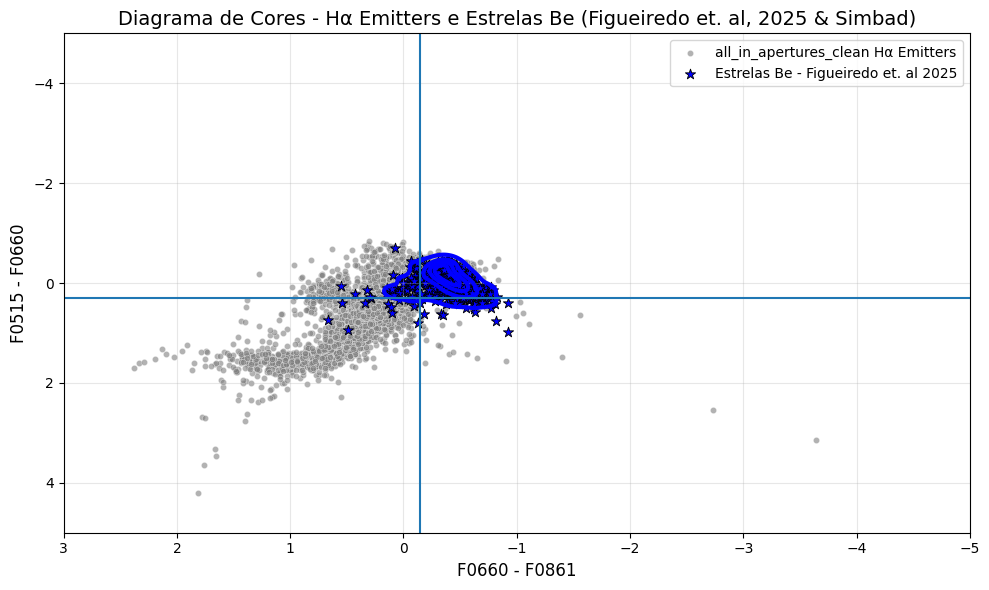

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurar a figura
plt.figure(figsize=(10, 6))

# Plotar o scatter dos dados principais
sns.scatterplot(y=all_in_apertures_clean['mag_psf_j0515'] - all_in_apertures_clean['mag_psf_j0660'], 
                x=all_in_apertures_clean['mag_psf_j0660'] - all_in_apertures_clean['mag_psf_j0861'], 
                label='all_in_apertures_clean Hα Emitters', color='gray', s=20, alpha=0.6)

# Plotar o scatter das estrelas Be
sns.scatterplot(y=be['mag_psf_j0515'] - be['mag_psf_j0660'], 
                x=be['mag_psf_j0660'] - be['mag_psf_j0861'], 
                label='Estrelas Be - Figueiredo et. al 2025', color='blue', s=60, 
                marker='*', edgecolor='black')

# Adicionar o contorno (densidade) para os dados 'be'
# Opção 1: Contorno de densidade (recomendado)
sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
            y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
            color='blue', linewidths=3, levels=5)

# Opção 2: Se preferir contornos mais suaves
# sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#             y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#             fill=True, alpha=0.3, color='blue', thresh=0.1)

# Opção 3: Se quiser um contorno com hexbin (para muitos pontos)
# plt.hexbin(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#            y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#            gridsize=30, cmap='Blues', alpha=0.7)

# Configurações dos eixos
plt.ylim(5, -5)
plt.xlim(3, -5)

plt.axvline(-0.15)
plt.axhline(0.3)

# Rótulos e título
plt.xlabel('F0660 - F0861', fontsize=12)
plt.ylabel('F0515 - F0660', fontsize=12)
plt.title('Diagrama de Cores - Hα Emitters e Estrelas Be (Figueiredo et. al, 2025 & Simbad)', fontsize=14)

# Adicionar grade para melhor visualização
plt.grid(True, alpha=0.3)

# Legenda
plt.legend(loc='best', fontsize=10)

# Ajustar layout
plt.tight_layout()

plt.show()

In [21]:
pss_be = all_in_apertures_clean[(all_in_apertures_clean['mag_psf_j0515'] - all_in_apertures_clean['mag_psf_j0660'] < 0.3)&(all_in_apertures_clean['mag_psf_j0660'] - all_in_apertures_clean['mag_psf_j0861'] < -0.15)]

In [22]:
pss_be

,Unnamed: 0,id,ra,dec,mag_psf_g,mag_psf_i,mag_psf_j0378,mag_psf_j0395,mag_psf_j0410,mag_psf_j0430,...,err_mag_psf_j0660,err_mag_psf_j0861,err_mag_psf_r,err_mag_psf_u,err_mag_psf_z,aperture_id,center_ra,center_dec,sep_arcsec,star_id
38,38,i06MC006309EBN,75.554877,-69.683640,19.501886,19.605484,20.031515,19.479977,19.416202,19.397149,...,0.051377,0.107542,0.044014,0.102235,0.090445,0,75.542759,-69.676398,30.152482,NaN
49,49,i06MC006309CMU,75.544095,-69.686311,18.984558,19.233815,19.539548,18.943454,18.819926,18.827800,...,0.039493,0.075930,0.030685,0.098544,0.057800,0,75.542759,-69.676398,35.724437,NaN
83,83,i06MC006309KYO,75.537923,-69.672658,19.245068,19.200207,19.913548,19.551007,19.210973,19.242889,...,0.038018,0.072698,0.034192,0.120009,0.060412,0,75.542759,-69.676398,14.761819,NaN
88,88,i06MC006309NBH,75.549478,-69.668188,18.596016,18.800116,19.218498,18.710099,18.488263,18.609272,...,0.027029,0.050592,0.023064,0.063165,0.042134,0,75.542759,-69.676398,30.727463,NaN
116,116,i06MC006309FMH,75.498358,-69.682725,19.435839,19.641900,20.401475,19.815006,19.378974,19.483527,...,0.055109,0.115396,0.042895,0.123587,0.085975,0,75.542759,-69.676398,59.998864,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22041,22870,i06MC0065095MM,81.867630,-69.578462,19.063640,19.268633,19.723212,19.231451,18.972437,19.069584,...,0.075986,0.111955,0.049296,0.082804,0.092383,996,81.898713,-69.590837,59.229478,NaN
22044,22873,i06MC0065094SN,81.864757,-69.580766,19.197177,19.523819,19.899463,19.167632,19.111262,19.013704,...,0.090287,0.132034,0.057923,0.081706,0.115193,996,81.898713,-69.590837,55.970035,NaN
22082,22911,i06MC003504BN1,92.050774,-67.269267,19.489842,19.619348,20.219604,19.672268,19.402665,19.538075,...,0.048555,0.147930,0.025058,0.203932,0.102378,997,92.086882,-67.262379,56.021627,NaN
22083,22912,i06MC003504D1V,92.060724,-67.265225,18.025748,18.358129,18.476824,18.049808,17.899007,17.999302,...,0.017662,0.045096,0.009392,0.051036,0.029981,997,92.086882,-67.262379,37.810413,NaN


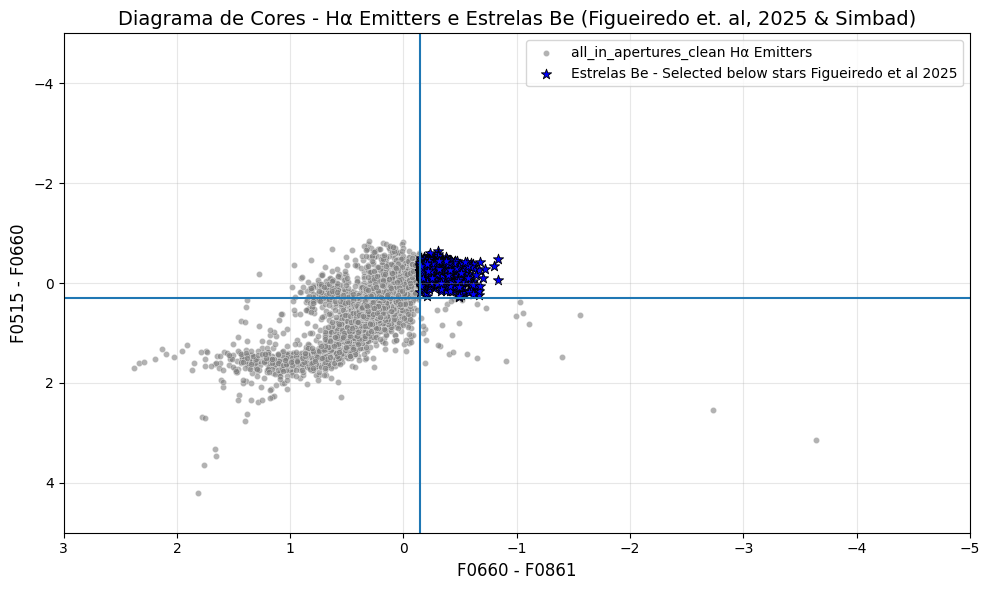

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configurar a figura
plt.figure(figsize=(10, 6))

# Plotar o scatter dos dados principais
sns.scatterplot(y=all_in_apertures_clean['mag_psf_j0515'] - all_in_apertures_clean['mag_psf_j0660'], 
                x=all_in_apertures_clean['mag_psf_j0660'] - all_in_apertures_clean['mag_psf_j0861'], 
                label='all_in_apertures_clean Hα Emitters', color='gray', s=20, alpha=0.6)

# Plotar o scatter das estrelas Be
sns.scatterplot(y=pss_be['mag_psf_j0515'] - pss_be['mag_psf_j0660'], 
                x=pss_be['mag_psf_j0660'] - pss_be['mag_psf_j0861'], 
                label='Estrelas Be - Selected below stars Figueiredo et al 2025', color='blue', s=60, 
                marker='*', edgecolor='black')

# Adicionar o contorno (densidade) para os dados 'be'
# Opção 1: Contorno de densidade (recomendado)
# sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#             y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#             color='blue', linewidths=3, levels=5)

# Opção 2: Se preferir contornos mais suaves
# sns.kdeplot(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#             y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#             fill=True, alpha=0.3, color='blue', thresh=0.1)

# Opção 3: Se quiser um contorno com hexbin (para muitos pontos)
# plt.hexbin(x=be['mag_psf_j0660'] - be['mag_psf_j0861'],
#            y=be['mag_psf_j0515'] - be['mag_psf_j0660'],
#            gridsize=30, cmap='Blues', alpha=0.7)

# Configurações dos eixos
plt.ylim(5, -5)
plt.xlim(3, -5)

plt.axvline(-0.15)
plt.axhline(0.3)

# Rótulos e título
plt.xlabel('F0660 - F0861', fontsize=12)
plt.ylabel('F0515 - F0660', fontsize=12)
plt.title('Diagrama de Cores - Hα Emitters e Estrelas Be (Figueiredo et. al, 2025 & Simbad)', fontsize=14)

# Adicionar grade para melhor visualização
plt.grid(True, alpha=0.3)

# Legenda
plt.legend(loc='best', fontsize=10)

# Ajustar layout
plt.tight_layout()

plt.show()

In [26]:
pss_be.to_csv('mc_fields_clean_1000_1rcmin_pss_be_stars.csv')

In [ ]:
pss_be

In [28]:
import pandas as pd
from astropy.io.votable import writeto, from_table
from astropy.table import Table
import numpy as np

def csv_to_votable(csv_file, vot_file=None, table_name="MyTable", 
                   description="Tabela astronômica", author="Astronomer"):
    """
    Converte um arquivo CSV para VOTable.
    
    Parameters:
    -----------
    csv_file : str
        Caminho para o arquivo CSV de entrada
    vot_file : str, optional
        Caminho para o arquivo VOTable de saída
        Se None, usa o mesmo nome do CSV com extensão .vot
    table_name : str
        Nome da tabela no VOTable
    description : str
        Descrição da tabela
    author : str
        Autor da tabela
    
    Returns:
    --------
    str: Caminho para o arquivo VOTable criado
    """
    
    # Carregar CSV
    print(f"Carregando {csv_file}...")
    df = pd.read_csv(csv_file)
    
    # Se vot_file não for especificado, criar nome baseado no CSV
    if vot_file is None:
        vot_file = csv_file.replace('.csv', '.vot').replace('.CSV', '.vot')
    
    # Converter tipos de dados do pandas para tipos compatíveis com VOTable
    # Isso evita problemas com tipos não suportados
    df_converted = df.copy()
    
    for col in df_converted.columns:
        # Converter booleanos para string (VOTable não suporta boolean diretamente)
        if df_converted[col].dtype == bool:
            df_converted[col] = df_converted[col].astype(str)
        # Converter objetos/complexos para string
        elif df_converted[col].dtype == object:
            try:
                # Tentar converter para numérico se possível
                df_converted[col] = pd.to_numeric(df_converted[col], errors='ignore')
            except:
                # Se falhar, manter como string
                df_converted[col] = df_converted[col].astype(str)
    
    # Criar Astropy Table
    astropy_table = Table.from_pandas(df_converted)
    astropy_table.meta['name'] = table_name
    
    # Criar VOTable
    votable = from_table(astropy_table)
    
    # Configurar metadados
    table = votable.resources[0].tables[0]
    table.name = table_name
    table.description = description    
    
    # Salvar VOTable
    print(f"Salvando VOTable em {vot_file}...")
    writeto(votable, vot_file)
    
    # Verificação
    print(f"\n=== RESUMO DA CONVERSÃO ===")
    print(f"Arquivo CSV: {csv_file}")
    print(f"Arquivo VOTable: {vot_file}")
    print(f"Número de linhas: {len(df)}")
    print(f"Número de colunas: {len(df.columns)}")
    print(f"Colunas: {', '.join(df.columns[:5])}{'...' if len(df.columns) > 5 else ''}")
    
    return vot_file

# ============================================
# USO PRÁTICO
# ============================================

# Exemplo 1: Conversão simples
vot_file = csv_to_votable(
    csv_file='mc_fields_clean_1000_1rcmin_pss_be_stars.csv',
    table_name="bes_fields",
    description="Tabela contendo fontes astronômicas com magnitudes S-PLUS",
    author="Marina Izabela - USP"
)


Carregando mc_fields_clean_1000_1rcmin_pss_be_stars.csv...
Salvando VOTable em mc_fields_clean_1000_1rcmin_pss_be_stars.vot...


/tmp/ipykernel_3443/399020764.py:50: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_converted[col] = pd.to_numeric(df_converted[col], errors='ignore')



=== RESUMO DA CONVERSÃO ===
Arquivo CSV: mc_fields_clean_1000_1rcmin_pss_be_stars.csv
Arquivo VOTable: mc_fields_clean_1000_1rcmin_pss_be_stars.vot
Número de linhas: 2420
Número de colunas: 34
Colunas: Unnamed: 0.1, Unnamed: 0, id, ra, dec...
